In [1]:
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy.sparse import csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split
from threadpoolctl import threadpool_limits
from wordcloud import WordCloud
import os
from pathlib import Path

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

plt.style.use('dark_background')

### Построение прототипа книжного рекомендательного сервиса
## 1. Знакомство с данными и EDA (Exploratory Data Analysis)

In [2]:
from genericpath import exists
path = 'data'
files_list = ["books.csv", "ratings.csv", "book_tags.csv", "tags.csv", "to_read.csv"]
os.makedirs(path, exist_ok=True)
if not all((Path(path) / filename).exists() for filename in files_list):
    kagglehub.dataset_download("zygmunt/goodbooks-10k", output_dir=str(path))

df_books = pd.read_csv(path+'/'+'books.csv')
df_ratings = pd.read_csv(path+'/'+'ratings.csv')
df_book_tags = pd.read_csv(path+'/'+'book_tags.csv')
df_tags = pd.read_csv(path+'/'+'tags.csv')
df_to_read = pd.read_csv(path+'/'+'to_read.csv')

dataset_dict = {'df_books':df_books,
                'df_ratings':df_ratings,
                'df_book_tags':df_book_tags,
                'df_tags':df_tags,
                'df_to_read':df_to_read}

## 1.1. Проведем первичный EDA , убедимся в отсустии пропусков или дублей.

In [3]:
for name,dataset in dataset_dict.items():
  display(Markdown(f"**{name}: {len(dataset):,} строк, {dataset.shape[1]} столбцов**"))
  display(dataset.head(3))
  display(Markdown(f"Пропущено значений: {dataset.isna().sum().sum()}"))
  display(Markdown(f"Полных дубликатов: {dataset.duplicated().sum()}"))

**df_books: 10,000 строк, 23 столбцов**

,id,book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,title,language_code,average_rating,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,"The Hunger Games (The Hunger Games, #1)",eng,4.34,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,Harry Potter and the Sorcerer's Stone (Harry P...,eng,4.44,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,"Twilight (Twilight, #1)",en-US,3.57,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...


Пропущено значений: 2975

Полных дубликатов: 0

**df_ratings: 981,756 строк, 3 столбцов**

...

Полных дубликатов: 0

**df_to_read: 912,705 строк, 2 столбцов**

,user_id,book_id
0,1,112
1,1,235
2,1,533


Пропущено значений: 0

Полных дубликатов: 0

Проверим подробнее df_books и df_ratings.

In [4]:
display(df_books.columns[df_books.isnull().sum()>0].to_list())

['isbn',
 'isbn13',
 'original_publication_year',
 'original_title',
 'language_code']

Заполним пропуски в original_title из title

In [5]:
df_books['original_title'] = df_books['original_title'].fillna(df_books['title'])
display(df_books.head(3))
display(Markdown(f"Пропущено значений df_books['original_title']: {df_books['original_title'].isna().sum()}"))

,id,book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,title,language_code,average_rating,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,"The Hunger Games (The Hunger Games, #1)",eng,4.34,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,Harry Potter and the Sorcerer's Stone (Harry P...,eng,4.44,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,"Twilight (Twilight, #1)",en-US,3.57,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...


Пропущено значений df_books['original_title']: 0

Проверим что, у нас датафрейме df_ratings нет ли пользователей, которые голосовали дважды.

In [6]:
df_ratings[df_ratings.duplicated(subset=["user_id", "book_id"],keep=False)].head(10)

,book_id,user_id,rating
1170,12,40251,4
1171,12,40251,4
2473,25,32635,5
2474,25,32635,5
2717,28,9011,2
2718,28,9011,1
2946,30,24582,4
2947,30,24582,3
2958,30,31760,4
2959,30,31760,4


Есть пользователи которые ставили оценку несколько раз но по разному, возьмем среднее и при обучении будем работать с ним.

In [7]:
ratings = df_ratings.groupby(["user_id", "book_id"], as_index=False)["rating"].mean()
book_columns = ["original_title", "authors", "average_rating", "ratings_count"]
print(f"После объединения: {len(ratings):,} оценок, "
      f"{ratings.user_id.nunique():,} пользователей, {ratings.book_id.nunique():,} книг")

После объединения: 979,478 оценок, 53,424 пользователей, 10,000 книг


## 1.2 Распределение оценок
Показываем исходные  оценки до усреднения повторных пар.

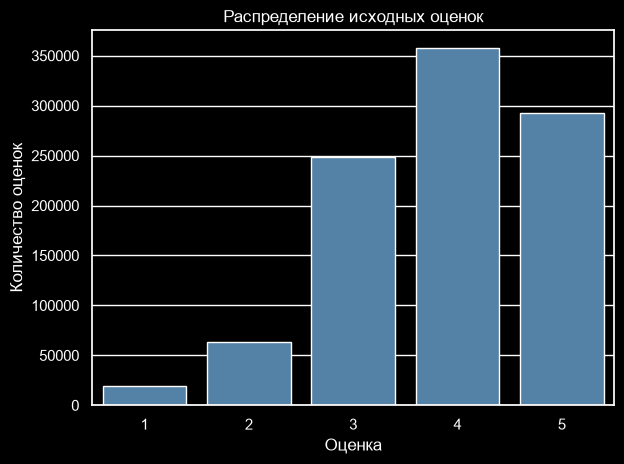

Доля оценок 4 и 5: 66.2%


In [8]:
ratings_count = df_ratings['rating'].value_counts().sort_index()
sns.barplot(x=ratings_count.index, y=ratings_count.values, color="steelblue")
plt.xlabel("Оценка")
plt.ylabel("Количество оценок")
plt.title("Распределение исходных оценок")
plt.tight_layout()
plt.show()
part_45=len(df_ratings.loc[df_ratings['rating']>=4, 'rating'])/len(df_ratings)
print(f"Доля оценок 4 и 5: {part_45:.1%}")

Оценки смещены в сторону высоких оценок, 4 и 5.

## 1.3 Активность пользователей и популярность книг

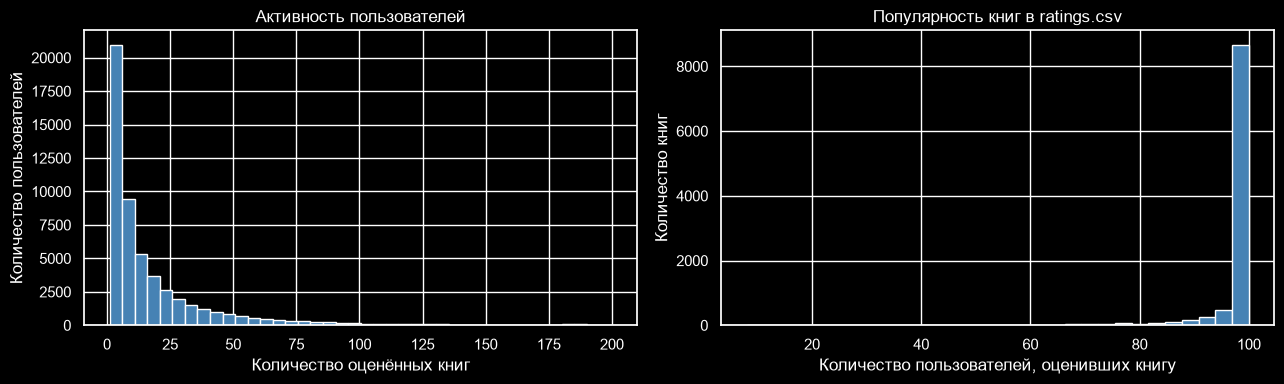

Пользователи с 1–5 книгами: 20,985 (39.3%)
90-й процентиль активности: 47 оценок
Книги с не более чем 40 оценками: 5
90-й процентиль популярности: 100 оценок
Заполненность матрицы оценок: 0.183%


In [9]:
user_activity = ratings.groupby("user_id").size()
book_activity = ratings.groupby("book_id").size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(user_activity, bins=40, color="steelblue")
axes[0].set(xlabel="Количество оценённых книг", ylabel="Количество пользователей",
            title="Активность пользователей")
axes[1].hist(book_activity, bins=30, color="steelblue")
axes[1].set(xlabel="Количество пользователей, оценивших книгу", ylabel="Количество книг",
            title="Популярность книг в ratings.csv")
plt.tight_layout()
plt.show()

active_threshold = user_activity.quantile(0.9)
popular_threshold = book_activity.quantile(0.9)
print(f"Пользователи с 1–5 книгами: {user_activity.le(5).sum():,} ({user_activity.le(5).mean():.1%})")
print(f"90-й процентиль активности: {active_threshold:g} оценок")
print(f"Книги с не более чем 40 оценками: {book_activity.le(40).sum():,}")
print(f"90-й процентиль популярности: {popular_threshold:g} оценок")
print(f"Заполненность матрицы оценок: {len(ratings) / (len(user_activity) * len(book_activity)):.3%}")


## 1.5. Частые теги



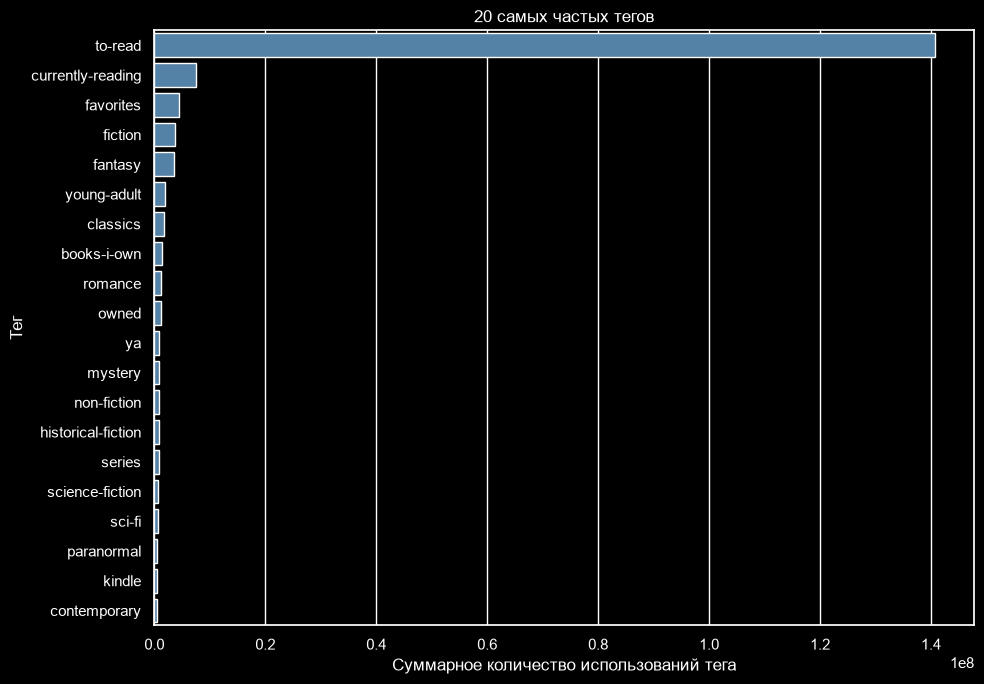

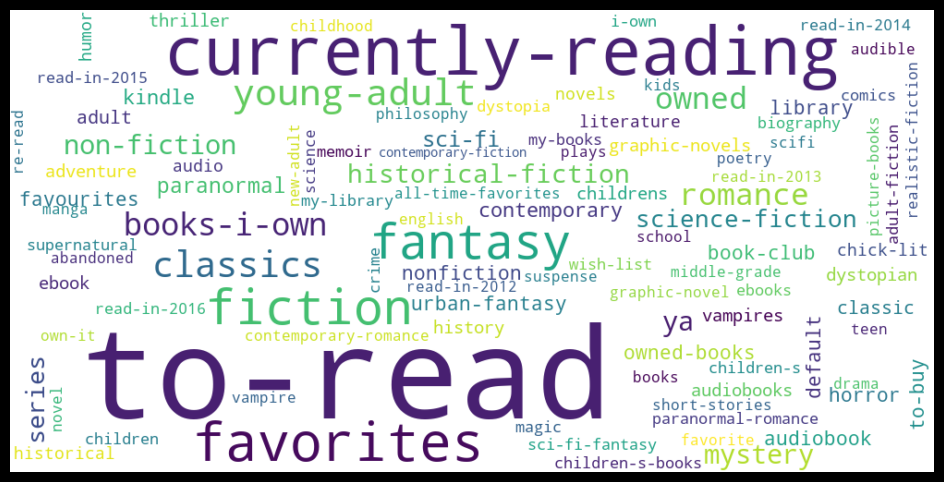

In [10]:
named_tags = df_book_tags.merge(df_tags, on="tag_id", how="left")
top_tags = named_tags.groupby("tag_name")["count"].sum().nlargest(100)

plt.figure(figsize=(10, 7))
sns.barplot(x=top_tags.head(20).values, y=top_tags.head(20).index, color="steelblue")
plt.xlabel("Суммарное количество использований тега")
plt.ylabel("Тег")
plt.title("20 самых частых тегов")
plt.tight_layout()
plt.show()

wordcloud = WordCloud(width=1000, height=500, background_color="white",
                      random_state=RANDOM_STATE).generate_from_frequencies(top_tags.to_dict())
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

# 1.6 Выводы
Оценки смещены в сторону высоких. У 39.3% пользователей не более 5 оценённых книг, у остальных 60.7% — больше 5. Матрица оценок очень разреженная.
Пользователи с 1–5 книгами: 20,985 (39.3%)
90-й процентиль активности: 47 оценок
Книги с не более чем 40 оценками: 5
90-й процентиль популярности: 100 оценок
Заполненность матрицы оценок: 0.183%

# 2. Базовая и контентная модели
## 2.1. Рекомендации по среднему рейтингу

In [11]:
def recommend_popular(books:pd.DataFrame, min_ratings:int=1000, n:int=10)-> list[int]:
  candidates = books.loc[books['ratings_count']>=min_ratings]
  return candidates.sort_values(["average_rating", "ratings_count"], ascending=False).head(n).index.tolist()


# отсортируем книги по id
catalog = df_books.set_index("id").sort_index()
recommended_ids = recommend_popular(catalog)
display(catalog.loc[recommended_ids, book_columns])

,original_title,authors,average_rating,ratings_count
id,,,,
3628,The Complete Calvin and Hobbes,Bill Watterson,4.82,28900
862,Words of Radiance,Brandon Sanderson,4.77,73572
3275,"Harry Potter Boxed Set, Books 1-5 (Harry Potte...","J.K. Rowling, Mary GrandPré",4.77,33220
8854,Mark of the Lion Trilogy,Francine Rivers,4.76,9081
7947,ESV Study Bible,"Anonymous, Lane T. Dennis, Wayne A. Grudem",4.76,8953
4483,It's a Magical World: A Calvin and Hobbes Coll...,Bill Watterson,4.75,22351
422,Complete Harry Potter Boxed Set,J.K. Rowling,4.74,190050
6361,There's Treasure Everywhere: A Calvin and Hobb...,Bill Watterson,4.74,16766
3753,"Harry Potter Collection (Harry Potter, #1-6)",J.K. Rowling,4.73,24618


## 2.2. Похожие книги по TF-IDF

In [12]:
# объединяем теги по книгам в одну строку, чтобы использовать их в качестве признаков
tags_by_book = named_tags.groupby("goodreads_book_id")["tag_name"].agg(" ".join)
profiles = df_books[["id", "book_id", "original_title"]].copy()
#объединяем теги с профилями книг
profiles = pd.merge(profiles, tags_by_book.rename("tags"), how="left", left_on="book_id", right_index=True)
profiles["text"] = (profiles["original_title"] + " " + profiles["tags"].fillna(""))

#создаём Series для быстрого поиска позиции книги по её id
profile_positions = pd.Series(np.arange(len(profiles)), index=profiles["id"])

# создаём TF-IDF матрицу для текстов профилей книг
tfidf = TfidfVectorizer(stop_words="english", max_features=20_000)
tfidf_matrix = tfidf.fit_transform(profiles["text"])
print("Размерность TF-IDF:", tfidf_matrix.shape)


def get_similar_books(book_id:int, n:int=5):
    #ищем позицию книги в профилях по её id
    position = profile_positions.loc[book_id]
    #ищем косинусное сходство между профилем книги и всеми остальными профилями
    scores = cosine_similarity(tfidf_matrix[position], tfidf_matrix).ravel()
    #исключаем саму книгу из результатов поиска
    scores[position] = -np.inf
    #ищем индексы n наиболее похожих книг и возвращаем их id в порядке убывания сходства
    nearest = np.argsort(scores, kind="stable")[-n:]
    return profiles.iloc[nearest]["id"].tolist()[::-1]  

#тестируем функцию поиска похожих книг на примере книги с индексом 10
example_book = int(df_books.iloc[10]["id"])
print("Похожие на:", catalog.loc[example_book, "original_title"])
display(catalog.loc[get_similar_books(example_book, n=10), book_columns])

Размерность TF-IDF: (10000, 20000)
Похожие на: The Kite Runner 


,original_title,authors,average_rating,ratings_count
id,,,,
67,A Thousand Splendid Suns,Khaled Hosseini,4.34,818742
359,And The Mountains Echoed,Khaled Hosseini,4.03,199326
28,Lord of the Flies,William Golding,3.64,1605019
8,The Catcher in the Rye,J.D. Salinger,3.79,2044241
5,The Great Gatsby,F. Scott Fitzgerald,3.89,2683664
595,A Separate Peace,John Knowles,3.56,155901
4,To Kill a Mockingbird,Harper Lee,4.25,3198671
90,The Outsiders,S.E. Hinton,4.06,659248
417,The Thirteenth Tale,Diane Setterfield,3.95,213200


## 3. Коллаборативная фильтрация (Collaborative Filtering — CF)
### 3.1. Матрица взаимодействий «пользователь — книга»

Используем явные оценки из `ratings`, где повторы уже усреднены.
Строки — пользователи, столбцы — книги. Ноль означает отсутствие оценки.
Для примера построим плотную матрицу средствами pandas на первых 1000 оценках.
На всех данных она занимает около 4 ГиБ, поэтому ниже используем разреженную матрицу.

In [13]:
df_user_book = ratings.head(1000).pivot(index="user_id", columns="book_id", values="rating").fillna(0)
item_similarity = pd.DataFrame(
    cosine_similarity(df_user_book.T),
    index=df_user_book.columns,
    columns=df_user_book.columns
)
display(df_user_book.iloc[:5, :5])
np.fill_diagonal(item_similarity.values, 0)
display(item_similarity.iloc[:5, :5])

display(f'размер в мегабайтах item_similarity: {item_similarity.memory_usage(deep=True).sum() / 1024 ** 2:.2f} МБ')
display(f'размер в мегабайтах df_user_book: {df_user_book.memory_usage(deep=True).sum() / 1024 ** 2:.2f} МБ')

# Освобождаем матрицы демонстрационного примера.
del df_user_book, item_similarity


book_id,78,108,120,135,137
user_id,,,,,
1,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0


book_id,78,108,120,135,137
book_id,,,,,
78,0.0,1.0,1.0,1.0,1.0
108,1.0,0.0,1.0,1.0,1.0
120,1.0,1.0,0.0,1.0,1.0
135,1.0,1.0,1.0,0.0,1.0
137,1.0,1.0,1.0,1.0,0.0


'размер в мегабайтах item_similarity: 5.87 МБ'

'размер в мегабайтах df_user_book: 0.56 МБ'

Плотная матрица хранит и пропуски, поэтому занимает много памяти.
Далее строим разреженную матрицу на всех оценках.


### 3.1. Матрица взаимодействий «пользователь — книга»

Используем явные оценки из `ratings`, где повторы уже усреднены.
Строки — пользователи, столбцы — книги. Ноль означает отсутствие оценки.
Матрица разреженная: храним только оценки, чтобы экономить память.

In [14]:
#данные для построения разреженной матрицы оценок
data = ratings['rating'].to_numpy(dtype=np.float32)
# Строки и столбцы для разреженной матрицы
row_indices =pd.Categorical(ratings['user_id'])
col_indices = pd.Categorical(ratings['book_id'])

# создаём разреженную матрицу оценок пользователей
user_book_matrix = csr_matrix(
    (data, (row_indices.codes, col_indices.codes)),
    shape=(len(row_indices.categories), len(col_indices.categories))
)


### 3.2. Схожесть книг

Транспонируем матрицу: теперь каждая строка — вектор оценок книги.
Вычисляем косинусную близость для всех пар книг. Диагональ обнуляем,
чтобы книга не была собственным соседом.


In [15]:
item_similarity = pd.DataFrame(
    cosine_similarity(user_book_matrix.T),
    index=col_indices.categories,
    columns=col_indices.categories
)
np.fill_diagonal(item_similarity.values, 0)
display(item_similarity.iloc[:5, :5])


,1,2,3,4,5
1,0.000000,0.555526,0.509152,0.464656,0.480233
2,0.555526,0.000000,0.520216,0.610741,0.587944
3,0.509152,0.520216,0.000000,0.359108,0.344423
4,0.464656,0.610741,0.359108,0.000000,0.703334
5,0.480233,0.587944,0.344423,0.703334,0.000000


### 3.3. Предсказание оценки

Из книг, которые пользователь уже оценил, выбираем K наиболее похожих
на заданную книгу с положительной близостью. Прогноз — обычное среднее
оценок этих соседей. Саму заданную книгу исключаем.
Если соседей меньше K, используем всех доступных. Если их нет — возвращаем
среднюю оценку пользователя, а для нового пользователя — общее среднее.


In [16]:
global_mean = float(ratings['rating'].mean())


def predict_rating(user_id, book_id, k=5):
    if not isinstance(k, (int, np.integer)) or k < 1:
        raise ValueError('k должно быть положительным целым числом')
    if user_id not in row_indices.categories:
        return global_mean

    user_position = row_indices.categories.get_loc(user_id)
    user_ratings = user_book_matrix.getrow(user_position).toarray().flatten()
    user_ratings = pd.Series(user_ratings, index=col_indices.categories)
    user_ratings = user_ratings[user_ratings > 0].drop(book_id, errors='ignore')
    if user_ratings.empty:
        return global_mean
    if book_id not in item_similarity.index:
        return float(user_ratings.mean())

    similarities = item_similarity.loc[book_id, user_ratings.index]
    neighbors = similarities[similarities > 0].nlargest(k).index
    if len(neighbors) == 0:
        return float(user_ratings.mean())
    return float(user_ratings.loc[neighbors].mean())


In [17]:
# Пример: прогноз для книги, которую пользователь ещё не оценивал.
example_user = row_indices.categories[0]
user_position = row_indices.categories.get_loc(example_user)
unrated = pd.Series(
    user_book_matrix.getrow(user_position).toarray().flatten(),
    index=col_indices.categories
)
example_book_cf = unrated[unrated == 0].index[0]
print('Пользователь:', example_user)
print('Книга:', catalog.loc[example_book_cf, 'original_title'])
print(f'Прогноз оценки: {predict_rating(example_user, example_book_cf, k=5):.2f}')


Пользователь: 1
Книга: The Hunger Games
Прогноз оценки: 3.00


### 3.4. Ограничения Item-Based CF
Для новых пользователей не будет релевантной истории. У редких книг мало общих читателей, сложно поймать сходство. Матрица сходства занимает много памяти. 

## 4. Матричные разложения (Matrix Factorization)
4.1 Используем библиотеку surprise для обучения модели SVD или любую другую библиотеку с данным алгоритмом.
4.2 Разделите данные на обучающую и тестовую выборку. Обучите модель и оцените ошибку предсказания (RMSE) на тесте.



In [18]:
data = Dataset.load_from_df(ratings[["user_id", "book_id", "rating"]], Reader(rating_scale=(1, 5)))
trainset, testset = train_test_split(data, test_size=0.2, random_state=RANDOM_STATE)


4.3 Функция get_recommendations
Реализуем функцию get_recommendations, которая для заданного пользователя возвращает топ-N книг с наибольшим предсказанным рейтингом.

In [19]:
model = SVD(n_factors=50, n_epochs=20, lr_all=0.01, reg_all=0.02, random_state=RANDOM_STATE)
model.fit(trainset)
predictions = model.test(testset)
rmse = accuracy.rmse(predictions)
mae = accuracy.mae(predictions)

RMSE: 0.8477
MAE:  0.6564


In [20]:
def get_recommendations(user_id: int, N: int = 5)-> list[int]:
    readed_books = ratings.loc[ratings['user_id'] == user_id, 'book_id'].values.tolist()
    candidates = catalog.loc[~catalog.index.isin(readed_books)]
    predictions = candidates.apply(lambda row: model.predict(user_id, row.name).est, axis=1).sort_values(ascending=False).head(N).index.to_list()
    return predictions


display(catalog.loc[get_recommendations(1, 5), book_columns])


,original_title,authors,average_rating,ratings_count
id,,,,
862,Words of Radiance,Brandon Sanderson,4.77,73572
7593,This is Water,David Foster Wallace,4.53,13312
9842,Humans of New York: Stories,Brandon Stanton,4.50,12527
5207,The Days Are Just Packed: A Calvin and Hobbes ...,Bill Watterson,4.68,19143
5580,The Calvin and Hobbes Lazy Sunday Book,Bill Watterson,4.66,18641


## 5. Оценка и сравнение моделей

Сравниваем Popularity, Item-Based CF и SVD на одном случайном разбиении 80/20.
В данных нет времени оценок, поэтому используем отложенный тест.
Все модели обучаем только на train; исключаем из рекомендаций только книги из train.
Кандидаты — весь каталог, а не только книги с известными тестовыми оценками.
Релевантные книги — тестовые оценки ≥ 4.

Для быстрого запуска берём 1000 случайных пользователей с хотя бы одной релевантной
тестовой книгой. Это оценка на подвыборке, включая пользователей без истории в train.
Пользователей без релевантных тестовых книг не оцениваем. Для полной оценки
задайте `MAX_USERS = None`. Выборка и параметры одинаковы для всех моделей;
параметры по результатам теста не подбираем.

### 5.1. Данные для оценки


In [21]:
data_eval = Dataset.load_from_df(
    ratings[['user_id', 'book_id', 'rating']], Reader(rating_scale=(1, 5))
)
trainset_eval, testset_eval = train_test_split(
    data_eval, test_size=0.2, random_state=RANDOM_STATE
)
train_df = pd.DataFrame(trainset_eval.build_testset(), columns=['user_id', 'book_id', 'rating'])
test_df = pd.DataFrame(testset_eval, columns=['user_id', 'book_id', 'rating'])

K = 5
THRESHOLD = 4
book_ids = catalog.index.sort_values().to_numpy()
train_user_items = train_df.groupby('user_id')['book_id'].agg(set).to_dict()
relevant_items = (test_df.loc[test_df['rating'] >= THRESHOLD]
                  .groupby('user_id')['book_id'].agg(set).to_dict())
test_users = np.array(sorted(relevant_items))
MAX_USERS = 1000  # None — оценивать всех пользователей
if MAX_USERS is not None and len(test_users) > MAX_USERS:
    test_users = np.random.default_rng(RANDOM_STATE).choice(
        test_users, size=MAX_USERS, replace=False
    )

print('Пользователей для оценки:', len(test_users))
print('Всего с релевантными тестовыми книгами:', len(relevant_items))
print('Без релевантных тестовых книг:', test_df['user_id'].nunique() - len(relevant_items))
results = []


Пользователей для оценки: 1000
Всего с релевантными тестовыми книгами: 34565
Без релевантных тестовых книг: 5785


### 5.2. Метрики

Precision@K — число попаданий / K; Recall@K — число попаданий / число релевантных
тестовых книг пользователя. nDCG@K учитывает позиции попаданий с весами
`1 / log2(позиция + 1)` и делится на идеальный DCG.
Общая функция ниже только считает метрики одного списка; рекомендации каждой
модели получаем отдельно. В таблице усредняем метрики по пользователям.


In [22]:
def ranking_metrics(recommended, relevant, k=5):
    hits = np.array([book_id in relevant for book_id in recommended[:k]], dtype=float)
    precision = hits.sum() / k
    recall = hits.sum() / len(relevant) if relevant else 0.0
    dcg = (hits / np.log2(np.arange(len(hits)) + 2)).sum()
    idcg = (1 / np.log2(np.arange(min(k, len(relevant))) + 2)).sum()
    ndcg = dcg / idcg if idcg > 0 else 0.0
    return precision, recall, ndcg


### 5.3. Popularity

Сохраняем подход этапа 2: сортируем по средней оценке, затем по числу оценок.
Статистики считаем только на train, без глобальных рейтингов Goodreads.
Порог здесь — хотя бы одна обучающая оценка: порог 1000 из этапа 2 относится
к внешней статистике Goodreads и не подходит для этой выборки.


In [23]:
train_books = train_df.groupby('book_id')['rating'].agg(
    average_rating='mean', ratings_count='count'
).sort_index()
popular_order = recommend_popular(train_books, min_ratings=1, n=len(train_books))

popularity_metrics = []
for user_id in test_users:
    seen = train_user_items.get(user_id, set())
    recommended = [book_id for book_id in popular_order if book_id not in seen][:K]
    popularity_metrics.append(ranking_metrics(recommended, relevant_items[user_id], K))

results.append(['Popularity', *np.mean(popularity_metrics, axis=0)])


### 5.4. Item-Based CF

Пересчитываем матрицу оценок и сходство только по train. Для каждой книги берём
до 5 самых похожих книг из истории пользователя с положительным сходством
и усредняем их оценки, как в этапе 3. При отсутствии соседей используем среднюю
оценку пользователя, для нового пользователя — среднюю train.
Считаем прогнозы сразу для всех книг через NumPy, чтобы не вызывать pandas
заново для каждой пары. При равенстве прогнозов порядок определяется ID книги.


In [24]:
cf_users = pd.Categorical(train_df['user_id'])
cf_books = pd.Categorical(train_df['book_id'], categories=book_ids)
cf_matrix = csr_matrix(
    (train_df['rating'].to_numpy(dtype=np.float32), (cf_users.codes, cf_books.codes)),
    shape=(len(cf_users.categories), len(book_ids))
)
cf_similarity = cosine_similarity(cf_matrix.T)
np.fill_diagonal(cf_similarity, 0)
cf_global_mean = train_df['rating'].mean()
CF_NEIGHBORS = 5

cf_metrics = []
for user_id in test_users:
    seen = train_user_items.get(user_id, set())
    scores = np.full(len(book_ids), cf_global_mean)
    if user_id in cf_users.categories:
        user_row = cf_matrix.getrow(cf_users.categories.get_loc(user_id))
        similarities = cf_similarity[:, user_row.indices]
        nearest = np.argsort(-similarities, axis=1, kind='stable')[:, :CF_NEIGHBORS]
        positive = np.take_along_axis(similarities, nearest, axis=1) > 0
        neighbor_ratings = user_row.data[nearest]
        counts = positive.sum(axis=1)
        scores[:] = user_row.data.mean()
        np.divide((neighbor_ratings * positive).sum(axis=1), counts,
                  out=scores, where=counts > 0)

    scores[np.isin(book_ids, list(seen))] = -np.inf
    order = np.argsort(-scores, kind='stable')
    recommended = book_ids[order[np.isfinite(scores[order])]][:K].tolist()
    cf_metrics.append(ranking_metrics(recommended, relevant_items[user_id], K))

results.append(['Item-Based CF', *np.mean(cf_metrics, axis=0)])


### 5.5. SVD

Обучаем SVD с параметрами этапа 4 на том же train. Предсказываем оценки всех
книг, отсутствующих в обучающей истории пользователя, и выбираем первые K.


In [25]:
svd_eval = SVD(n_factors=50, n_epochs=20, lr_all=0.01,
               reg_all=0.02, random_state=RANDOM_STATE)
svd_eval.fit(trainset_eval)

svd_metrics = []
for user_id in test_users:
    seen = train_user_items.get(user_id, set())
    candidates = [book_id for book_id in book_ids if book_id not in seen]
    scores = pd.Series(
        [svd_eval.predict(user_id, book_id).est for book_id in candidates],
        index=candidates, dtype=float
    )
    recommended = scores.nlargest(K).index.tolist()
    svd_metrics.append(ranking_metrics(recommended, relevant_items[user_id], K))

results.append(['SVD', *np.mean(svd_metrics, axis=0)])


### 5.6. Сводная таблица

Для всех трёх метрик больше — лучше. Неизвестные оценки не считаем релевантными,
поэтому при разреженной истории абсолютные значения метрик могут быть низкими.
Результаты зависят от выбранного разбиения и подвыборки пользователей;
одного запуска недостаточно, чтобы утверждать статистически значимое превосходство.


In [26]:
comparison = pd.DataFrame(
    results, columns=['Модель', f'Precision@{K}', f'Recall@{K}', f'nDCG@{K}']
).set_index('Модель')
display(comparison.round(5))


,Precision@5,Recall@5,nDCG@5
Модель,,,
Popularity,0.0008,0.00131,0.00095
Item-Based CF,0.0004,0.00008,0.00055
SVD,0.0004,0.00114,0.00064


## 6. Гибридизация и выводы

Методы улучшения рекомендаций
1. Для новых пользователей мы можем рекомендовать, книги с самым высоким рейтингом, для новых книг мы можем операться на контентные рекомендации
2. Для книг без взаимодействий коллаборативная фильтрация не работает — нет вектора скрытых факторов. Решение — контентные рекомендации:
Строим TF-IDF или эмбеддинги на основе метаданных книги: название, автор, жанры, теги, описание.
Новую книгу можно сразу рекомендовать, находя похожие по содержанию книги и подставляя их в рекомендации пользователям, которым нравятся похожие. 
По мере поступления оценок вес контентной составляющей снижается, а коллаборативной — растёт.
3. Используем SVD (матричная факторизация) — раскладываем матрицу рейтингов на скрытые факторы пользователей и книг. Качество предсказаний зависит от количества и структуры оценок; 5–10 оценок сами по себе не гарантируют устойчивый результат.

Метрики оценивают попадания в известные релевантные книги из теста. При разреженных данных многие потенциально интересные книги не имеют тестовой оценки и не засчитываются как попадания. Поэтому низкие значения метрик сами по себе не доказывают, что модели не находят закономерности; для вывода о качестве нужны дополнительные проверки.
